# Swiggy Sales Python Project

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Import Data

In [8]:
df = pd.read_excel("C:/Users/HP/Desktop/Swiggy Sales-Python Project/swiggy_data.xlsx")

In [9]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [10]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### Meta Data

In [15]:
print("No.Of Rows:", df.shape[0])

No.Of Rows: 197430


In [16]:
print("No.of Columns:", df.shape[1])

No.of Columns: 10


### Data Types

In [17]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

# KPI's

### Total Sales

In [22]:
total_sales = df["Price (INR)"].sum()
print("Total Sales(INR):",round(total_sales,2))

Total Sales(INR): 53012505.77


### Average Rating

In [24]:
average_rating = df["Rating"].mean()
print("Average Rating:",round(average_rating,1))

Average Rating: 4.3


### Average Order Value

In [25]:
avg_order_value = df["Price (INR)"].mean()
print("Average Order Value(INR):",round(avg_order_value,2))

Average Order Value(INR): 268.51


### Ratings Count 

In [26]:
ratings_count = df["Rating Count"].sum()
print("Ratings Count:",round(ratings_count,2))

Ratings Count: 5591574


### Total Orders

In [29]:
total_orders=len(df)
print("Total Orders:",round(total_orders,2))

Total Orders: 197430


# CHARTS Design

### Monthly Sales Trend

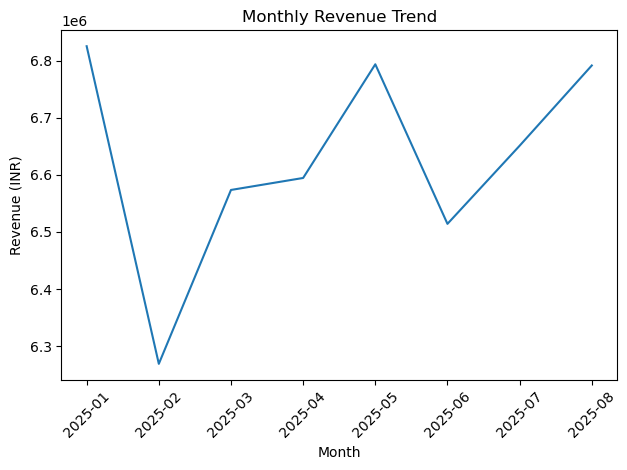

In [37]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df ["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth") ["Price (INR)"].sum().reset_index()

plt.figure()

plt.plot(monthly_revenue ["YearMonth"], monthly_revenue ["Price (INR)"])

plt.xticks (rotation=45)

plt.xlabel("Month")

plt.ylabel("Revenue (INR)")

plt.title("Monthly Revenue Trend")

plt.tight_layout()

plt.show()

### Daily Sales Trend

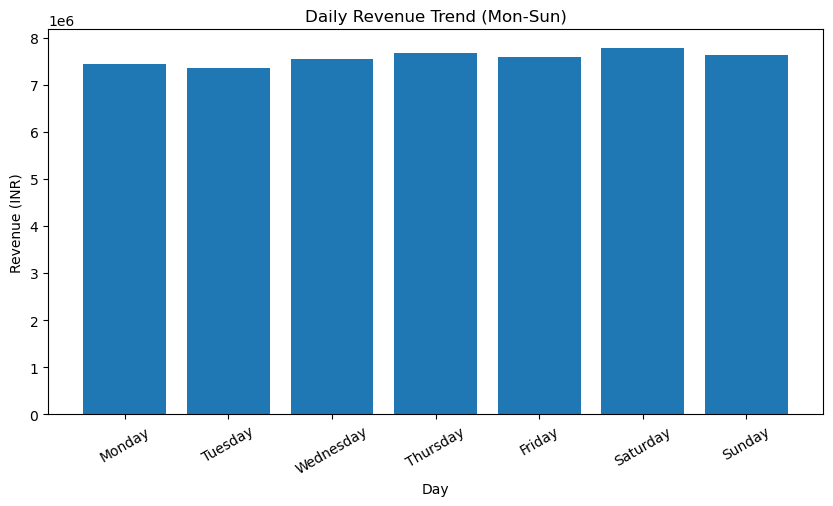

In [39]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (

    df.groupby("DayName") ["Price (INR)"]
    .sum()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks (rotation=30)
plt.show()

### Total Sales by Food Type (Veg vs Non-Veg)

In [40]:
non_veg_keywords = [
"chicken", "egg", "fish", "mutton",
"prawn", "biryani", "kabab", "kebab",
"non-veg", "non veg"]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

In [41]:
food_revenue = (

df.groupby("Food Category") ["Price (INR)"]
.sum()
.reset_index()
)

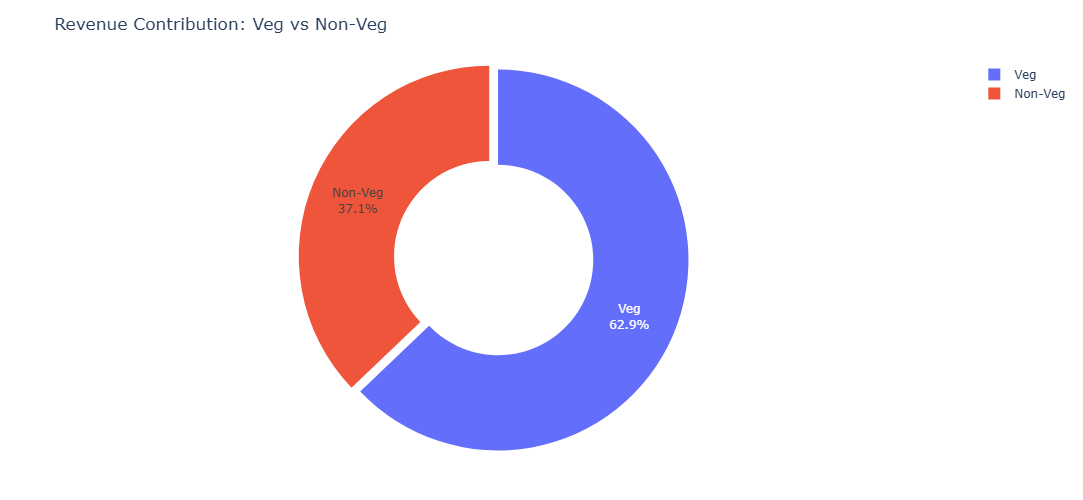

In [43]:
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)
fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]
) 
fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()

### Total Sales by State

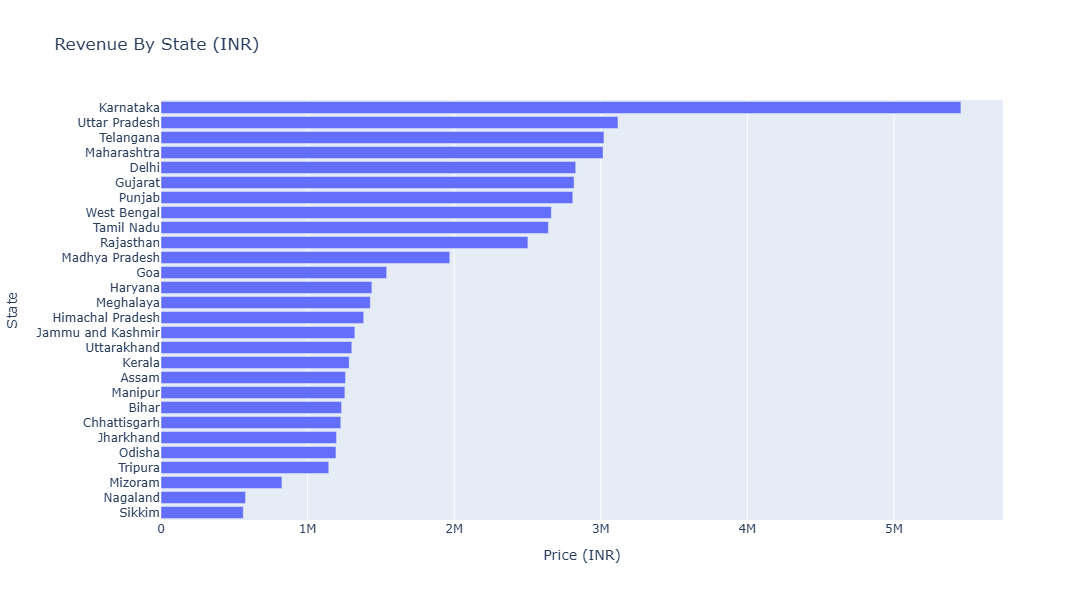

In [45]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
    .sort_values("Price (INR)",ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue By State (INR)"
)
fig.update_layout(height=600,yaxis=dict(autorange="reversed"))
fig.show()

### Quarterly Performance Summary

In [47]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df ["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
quarterly_summary=(
    df.groupby("Quarter", as_index=False)
    .agg(
    Total_Sales=("Price (INR)", "sum"), 
    Avg_Rating=("Rating", "mean"),
    Total_Orders=("Order_Date", "count")
    )
    .sort_values("Quarter")
)
quarterly_summary ["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders,Avg Rating
0,2025Q1,19667822.0,4.342643,73096,4.34
1,2025Q2,19902257.0,4.340011,74163,4.34
2,2025Q3,13442427.0,4.342359,50171,4.34


### Top 5 Cities by Sales

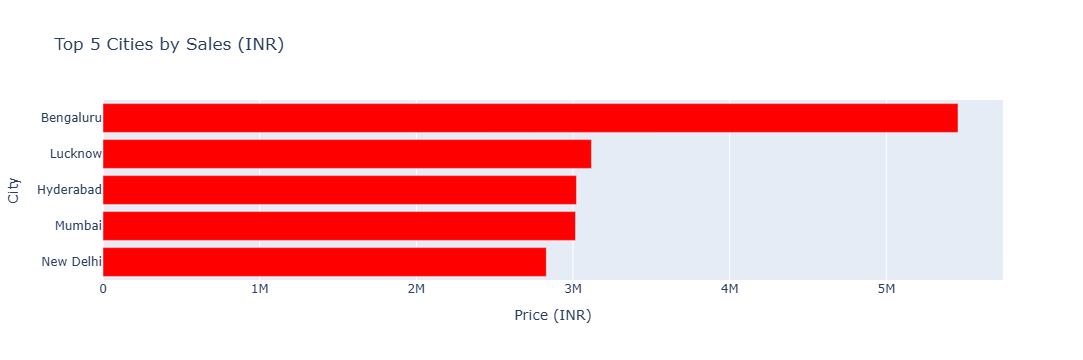

In [48]:
top_5_cities = (
    df.groupby("City") ["Price (INR)"]
    .sum()
    .nlargest (5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)

fig.show()

### Weekly Trend Analysis 

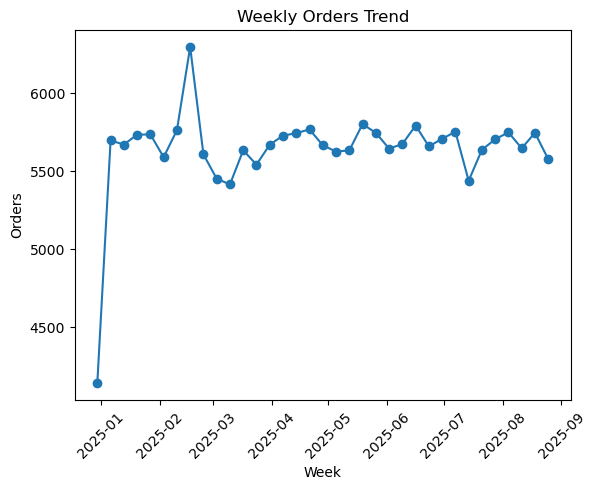

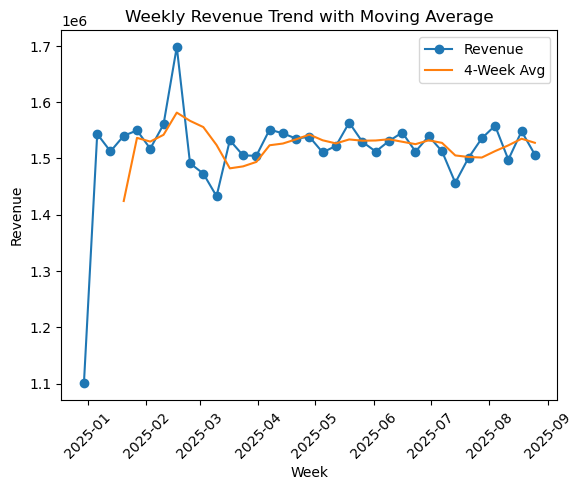

In [54]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['week_start'] = df['Order Date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_sales = df.groupby('week_start').agg({
    'Order Date': 'count',        # number of orders
    'Price (INR)': 'sum'          # total revenue
}).reset_index()

weekly_sales.rename(columns={
    'Order Date': 'orders',
    'Price (INR)': 'revenue'
}, inplace=True)
plt.figure()
plt.plot(weekly_sales['week_start'], weekly_sales['orders'], marker='o')
plt.title("Weekly Orders Trend")
plt.xlabel("Week")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

weekly_sales['rolling_avg'] = weekly_sales['revenue'].rolling(window=4).mean()

plt.figure()
plt.plot(weekly_sales['week_start'], weekly_sales['revenue'], marker='o', label='Revenue')
plt.plot(weekly_sales['week_start'], weekly_sales['rolling_avg'], label='4-Week Avg')
plt.title("Weekly Revenue Trend with Moving Average")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.show()